# Question 4: Monte Carlo Methods

A model for a stock $S$ is given by the stochastic differential equation $$\text{d}S_t=rS_t\text{d}t+\alpha S_0^\beta S_te^{\gamma\sin\delta t}\text{d}W_t^Q,$$ where $W^Q$ is a Brownian motion under the risk-neutral probability $Q$. Here $r=0.05$, $\alpha=0.3$, $\beta=-0.2$, $\gamma = 0.05$ and $\delta = 3\pi$ are parameters and $S_0=100$ is the initial stock price. The aim of this part of the project is to study a European style derivative where the payoff $f(S_T)$ at time $T=1$ is only paid if the stock price has not hit a barrier $L=110$, in other words, the payoff at time $T=1$ is
$$f_L(S, (S_t)_{t\in[0,T]})=\begin{cases}f(S_T) & \text{if }\max_{t\in[0,T]}S_t<L\\0 & \text{if }\max_{t\in[0,T]}S_t\geq L\end{cases}$$
The price of this derivative at time 0 is then $e^{-rT}E^Q(f_L(S, (S_t)_{t\in[0,T]}))$.

In [ ]:
# References for numpy functions used in this code:
# np.max(): returns the maximum of an array along an axis
# https://numpy.org/doc/stable/reference/generated/numpy.max.html

# np.maximum(): maximum of two input values
# https://numpy.org/doc/stable/reference/generated/numpy.maximum.html

# np.cumsum(): cumulative summation across an array
# https://numpy.org/doc/stable/reference/generated/numpy.cumsum.html

# This section is for question 4.2
# Import packages
import math
import numpy as np
from scipy.stats import norm

# Define given parameters
r = 0.05
alpha = 0.3
beta = -0.2
gamma = 0.05
delta = 3*math.pi
T = 1

# Define the initial stock price
S0 = 100

# Define the barrier price
L = 110

# Define our barrier payoff function
def BPayoff(S, K, L, payoff):
  step = np.max(S, axis = 1) < L
  ST = S[:, -1]
  return step * payoff(ST, K)

# Define our derivative payoff function
def call(S, K):
  return np.maximum(S - K, 0)

# Euler Scheme Option Pricing Function
def EACS(S0, K, L, r, T, M, N, payoff, confidence = 0.95, seed = 2026):
  """Euler Scheme Pricing of European Option using a Control Variate and Antithetic Sampling
  Arguments:
    S0: Initial Stock Value
    K: Strike Price
    L: Barrier Price
    r: interest rate
    T: time horizon
    M: number of iterations in time
    N: number of Paths
    confidence: percentage confidence (i.e. 95% as 0.95)
    f: option payoff function
  Returns:
    eta: adjusted option price estimate
    b: control variate value
    se: standard error of result
    ci: confidence interval of result
  """
  times = np.linspace(0, T, M + 1)
  dt = times[1] - times[0]
  pt = r - 0.5 * (alpha**2) * (S0**(2 * beta)) * np.exp(2 * gamma * np.sin(delta * times[:-1]))
  qt = alpha * (S0**(beta)) * np.exp(gamma * np.sin(delta * times[:-1]))

  Y0 = math.log(S0)
  Cv = S0 * math.exp(r * T)

  rng = np.random.default_rng(seed)
  dZ = rng.normal(0, scale = math.sqrt(dt), size = (N, M))

  dY = pt * dt + qt * dZ
  dYa = pt * dt - qt * dZ

  Y = np.empty((N, M + 1))
  Ya = np.empty((N, M + 1))

  Y[:, 0] = Y0
  Ya[:, 0] = Y0

  Y[:, 1:] = Y0 + np.cumsum(dY, axis = 1)
  Ya[:, 1:] = Y0 + np.cumsum(dYa, axis = 1)

  St = np.exp(Y)
  Sta = np.exp(Ya)

  f = BPayoff
  X = 0.5 * (f(St, K, L, payoff) + f(Sta, K, L, payoff))
  C = 0.5 * (St[:,-1] + Sta[:, -1])

  b = np.sum((X - X.mean()) * (C - C.mean())) / np.sum((C - C.mean())**2)
  H = X - b * (C - Cv)

  eta = np.exp(-r*T) * H.mean()
  se = np.exp(-r*T) * np.sqrt(np.sum((H - H.mean())**2) / (N * (N - 1)))

  z = norm.ppf(0.5 + confidence / 2)
  ci = (eta - z * se, eta + z * se)
  return eta, se, ci

# This section is for question 4.3
# run our function using given parameters:
K = 100
M = 1000

eta, se, ci = EACS(S0, K, L, r, T, M, 2000, call)

print(f"Estimated option price: {eta:.6f}\nStandard Error: {se:.6f}\nConfidence interval: {ci[0]:.6f}-{ci[1]:.6f}\nConfidence interval length: {ci[1]-ci[0]:.6f}")

Estimated option price: 0.504101
Standard Error: 0.023449
Confidence interval: 0.458141-0.550060
Confidence interval length: 0.091920


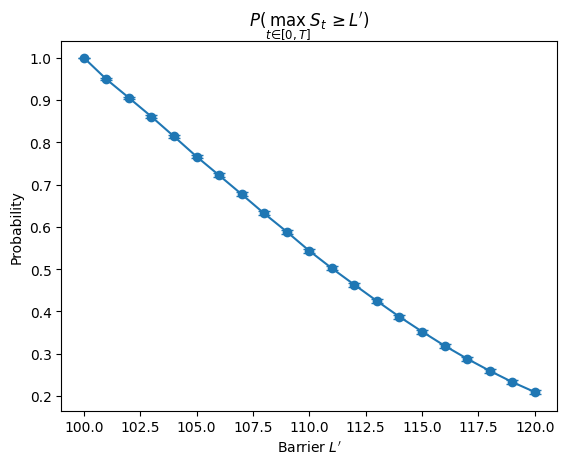


Number of simulated paths $N$: 40000

L': 100, Probability of condition: 1.00, Confidence interval: 1.0000 - 1.0000, Interval length: 0.0000
L': 101, Probability of condition: 0.95, Confidence interval: 0.9470 - 0.9513, Interval length: 0.0043
L': 102, Probability of condition: 0.91, Confidence interval: 0.9023 - 0.9080, Interval length: 0.0057
L': 103, Probability of condition: 0.86, Confidence interval: 0.8573 - 0.8640, Interval length: 0.0068
L': 104, Probability of condition: 0.81, Confidence interval: 0.8100 - 0.8176, Interval length: 0.0076
L': 105, Probability of condition: 0.77, Confidence interval: 0.7621 - 0.7704, Interval length: 0.0083
L': 106, Probability of condition: 0.72, Confidence interval: 0.7176 - 0.7264, Interval length: 0.0088
L': 107, Probability of condition: 0.68, Confidence interval: 0.6726 - 0.6818, Interval length: 0.0092
L': 108, Probability of condition: 0.63, Confidence interval: 0.6269 - 0.6364, Interval length: 0.0095
L': 109, Probability of condition:

In [ ]:
# This code is for question 4.4
# Calculating the probabilities that a stock will exceed the barrier L'
# For every time in [0, T]:

from scipy.stats import norm
import matplotlib.pyplot as plt


def PGT(S0, r, T, M, N, confidence = 0.95, seed = 2026):
  """Function to show the probability of a stock exceeding the barrier
  price L'
  Arguments:
    S0: inital stock value
    K: strike price
    r: problem parameter
    T: time horizon
    M: number of discritized points in time
    N: number of paths simulated
    confidence: the percentage confidence
    seed: random number generator seed for reproducibility
  Outputs:
    Probs: array of probabilities that a stock exceeds the barrier
    ci: the confidence interval of an output probability
    Plot: a line plot showing the probability alongside an error bar confidence interval
  """
  times = np.linspace(0, T, M + 1)
  dt = times[1] - times[0]
  pt = r - 0.5 * (alpha**2) * (S0**(2 * beta)) * np.exp(2 * gamma * np.sin(delta * times[:-1]))
  qt = alpha * (S0**(beta)) * np.exp(gamma * np.sin(delta * times[:-1]))
  Y0 = math.log(S0)
  rng = np.random.default_rng(seed)
  dZ = rng.normal(0, scale = math.sqrt(dt), size = (N, M))
  dY = pt * dt + qt * dZ
  Y = np.empty((N, M + 1))
  Y[:, 0] = Y0
  Y[:, 1:] = Y0 + np.cumsum(dY, axis = 1)
  S_max = np.max(np.exp(Y), axis = 1)
  Ls = np.arange(100,121,1)
  bigS = S_max[None,:] >= Ls[:, None]
  Probs = bigS.mean(axis = 1)
  se = np.sqrt(Probs * (1 - Probs) / N)

  z = norm.ppf(0.5 + confidence / 2)
  cit = Probs + z * se
  cib = Probs - z * se

  plt.errorbar(Ls, Probs, yerr = z*se, fmt = 'o-', capsize = 4)
  plt.xlabel("Barrier $L'$")
  plt.ylabel("Probability")
  plt.title(r"$P(\max_{t\in[0,T]} S_t \geq L')$")
  plt.show()

  print(f"\nNumber of simulated paths $N$: {N}\n")
  for i in range(len(Ls)):
    print(f"L': {Ls[i]}, Probability of condition: {Probs[i]:.2f}, Confidence interval: {cib[i]:.4f} - {cit[i]:.4f}, Interval length: {cit[i]-cib[i]:.4f}")

  return Probs, cit - cib

Probs, cil = PGT(S0, r, T, M, 40000)

See `Part_4.pdf` for tabular results.

Note: This result makes sense! As the barrier gets closer to the initial stock price, the stock needs to increase by less each time in order to succeed it.